# Ingestão, Análise Exploratória e Limpeza

In [1]:
import pandas as pd
df = pd.read_csv('dados_dataset/turnover_data.csv')
print("dataset importado com sucesso")

dataset importado com sucesso


## Análise Exploratória

In [2]:
# Visualizando as primeiras 10 linhas
print(df.head(10))

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   
5   32        No  Travel_Frequently       1005  Research & Development   
6   59        No      Travel_Rarely       1324  Research & Development   
7   30        No      Travel_Rarely       1358  Research & Development   
8   38        No  Travel_Frequently        216  Research & Development   
9   36        No      Travel_Rarely       1299  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8      

In [3]:
# Visualizando as dimensões
df.shape

(1470, 35)

In [4]:
# Tipo de dados de cada atributo
df.dtypes

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

In [5]:
# Verificação de nulos
print("\nValores nulos por coluna:")
print(df.isnull().sum())


Valores nulos por coluna:
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurren

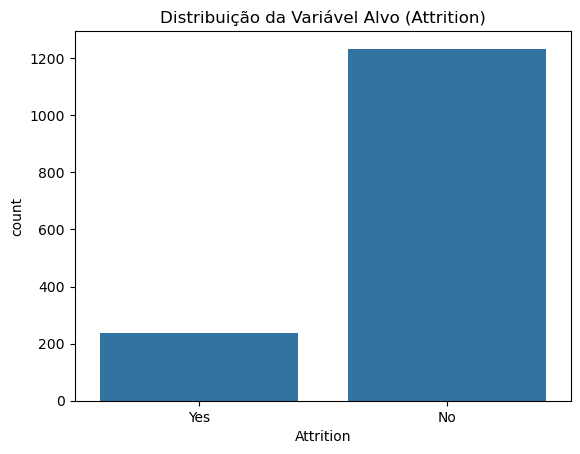

In [6]:
# Visualização da distribuição do Target (Desbalanceamento)
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Attrition', data=df)
plt.title('Distribuição da Variável Alvo (Attrition)')
plt.show()

## Diagnóstico e Estratégia de Limpeza

A análise dos dados confirmou que não há valores nulos, dispensando correções imediatas. No entanto, o dataset precisa de ajustes para ser processado pelos modelos: removeremos colunas irrelevantes (IDs e dados constantes) para evitar ruído, converteremos a variável alvo (Attrition) para formato numérico (0 ou 1) e transformaremos as variáveis de texto em numéricas (via One-Hot Encoding). Além disso, notamos que o número de funcionários que permanecem é muito maior do que os que saem. Por isso, usaremos técnicas de balanceamento mais adiante, garantindo que o modelo aprenda a identificar corretamente ambos os casos.

## Limpeza

In [7]:
# Removendo colunas
colunas_inuteis = ['EmployeeCount', 'EmployeeNumber', 'StandardHours', 'Over18']
df = df.drop(columns=colunas_inuteis, errors='ignore')

# Conversão da variável alvo para binário (0/1)
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# One-Hot Encoding das variáveis categóricas.
df = pd.get_dummies(df, drop_first=True)

# Salvar para o pipeline de experimentos
df.to_csv('dados_dataset/dados_limpos.csv', index=False)
print("Dados limpos salvos em novo dataset")

Dados limpos salvos em novo dataset
